# `drlib` tutorial — using the bundled `PRJCT/Data` reference dataset

This notebook walks through every public class shipped with `drlib`:

| Section | Topic | Backed by |
|---------|-------|-----------|
| 1 | Load a raw FMR dataset from four `.mat` files | `drlib.load_mat_dataset` |
| 2 | Compare the three FMR background-correction techniques side by side | `drlib.compare_techniques` |
| 3 | Build a `Spectrum` from in-memory arrays | `drlib.Spectrum.from_arrays` |
| 4 | Extract a `Linecut` at one field and fit a `dS21` peak | `drlib.Linecut.one_peak` |
| 5 | Overlay a series of fits on top of the spectrum | `drlib.Spectrum.scatter_plot` |
| 6 | Coplanar-waveguide (CPW) Biot–Savart field & k-spectrum | `drlib.CPW` |
| 7 | REXS reciprocal-space simulator (skyrmion / helical / coexistence) | `drlib.REXS2D` |

**All cells run on the dataset bundled at `<repo>/../Data/`** — there is nothing to download.
If you have your own LabView-folder measurement, the very last cell shows how to use the classical `Spectrum(path=…)` constructor instead.

## 0. Setup

In [1]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import drlib
from drlib import (
    Spectrum, Linecut, CPW, REXS2D,
    compare_techniques, load_mat_dataset,
    derivative, derivative_divide,
    dS21, Lorentzian,
)

print('drlib', drlib.__version__)

# Locate a usable dataset.  Search order:
#   1) $DRLIB_DATA_DIR                       (override via environment variable)
#   2) <notebook_dir>/examples/data           (downsampled copy shipped with the repo)
#   3) <notebook_dir>/../Data                 (full-resolution copy on the author's machine)
#   4) <notebook_dir>/Data                    (next-to-package layout)
#   5) F:/Sina_Data_Job2026/PRJCT/Data        (legacy absolute path)
def _find_data_dir():
    env = os.environ.get('DRLIB_DATA_DIR')
    if env and Path(env).is_dir():
        return str(Path(env).resolve())
    here = Path('.').resolve()
    for cand in (here / 'examples' / 'data',
                 here / '..' / 'Data',
                 here / 'Data',
                 Path(r'F:/Sina_Data_Job2026/PRJCT/Data')):
        p = cand.resolve()
        if (p / 'MLIN.mat').is_file():
            return str(p)
    raise FileNotFoundError('Could not locate the FMR dataset — set DRLIB_DATA_DIR.')

DATA_DIR = _find_data_dir()
print('DATA_DIR =', DATA_DIR)

drlib 1.1.0
DATA_DIR = F:\Sina_Data_Job2026\PRJCT\My LIbrary\DrLib\examples\data


## 1. Load the raw FMR dataset

`drlib.load_mat_dataset` reads the four reference `.mat` files in `PRJCT/Data/`:

| File | Shape | Meaning |
|------|-------|---------|
| `freq.mat`          | `(N_freq, N_field)` | Frequency grid (Hz) |
| `MLIN.mat`          | `(N_freq, N_field)` | Linear magnitude of the measured S-parameter |
| `MLIN_REF.mat`      | `(N_freq, N_field)` | Reference baseline (1-D in freq, tiled in field) |
| `sample_field.mat`  | `(N_field, …)`      | Magnetic-field grid (mT) — reduced to 1-D on load |

See `DATA_SHAPES.md` for the full convention.

In [2]:
freq, field, mlin, mlin_ref = load_mat_dataset(DATA_DIR)

print('freq    ', freq.shape,     '  Hz   range', freq.min(),     '..', freq.max())
print('field   ', field.shape,    '  mT   range', field.min(),    '..', field.max())
print('mlin    ', mlin.shape,     '       range', mlin.min(),     '..', mlin.max())
print('mlin_ref', mlin_ref.shape, '       range', mlin_ref.min(), '..', mlin_ref.max())

freq     (2501, 101)   Hz   range 10000000.0 .. 10000000000.0
field    (101,)   mT   range 0 .. 200
mlin     (2501, 101)        range 0.289224 .. 1.00459
mlin_ref (2501, 101)        range -0.3193213 .. 0.3770135


Quick look at the raw magnitude — `mlin` is the linear |S21| as a function of frequency (rows) and field index (columns).

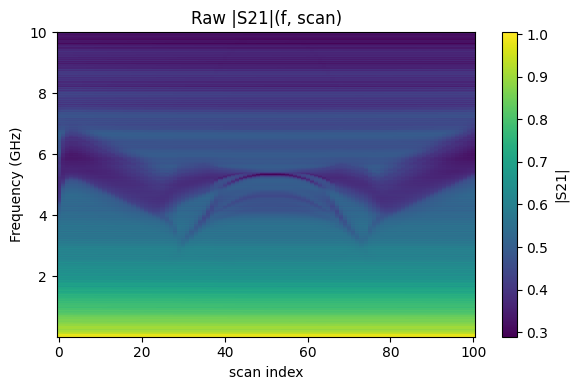

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
scan_idx = np.arange(mlin.shape[1])[None, :].repeat(mlin.shape[0], axis=0)
im = ax.pcolormesh(scan_idx, freq * 1e-9, mlin, cmap='viridis', shading='auto')
ax.set_xlabel('scan index'); ax.set_ylabel('Frequency (GHz)')
ax.set_title('Raw |S21|(f, scan)')
fig.colorbar(im, ax=ax, label='|S21|')
fig.tight_layout()

## 2. Compare the three FMR background-correction techniques

`drlib.compare_techniques` is a one-call helper that lays out the three
standard FMR plotting techniques side by side:

1. **`ΔS21`** &mdash; plain reference subtraction `S21(H) − S21(H_ref)`.
   When `saturation_index` is given, the reference is the *measured*
   line at that scan; otherwise the user-supplied `mlin_ref` is used.
2. **Derivative** &mdash; `∂S21/∂H` along the field axis (`drlib.derivative`).
3. **Derivative-divide** &mdash; `(∂S21/∂H) / S21`, the standard 'dd'
   technique that removes slow multiplicative backgrounds
   (`drlib.derivative_divide`, Maier-Flaig *et al.*, arXiv:1705.05694).

For this dataset `MLIN_REF` is not a true saturation measurement, so the
`saturation_index` form gives the cleanest ΔS21 panel.

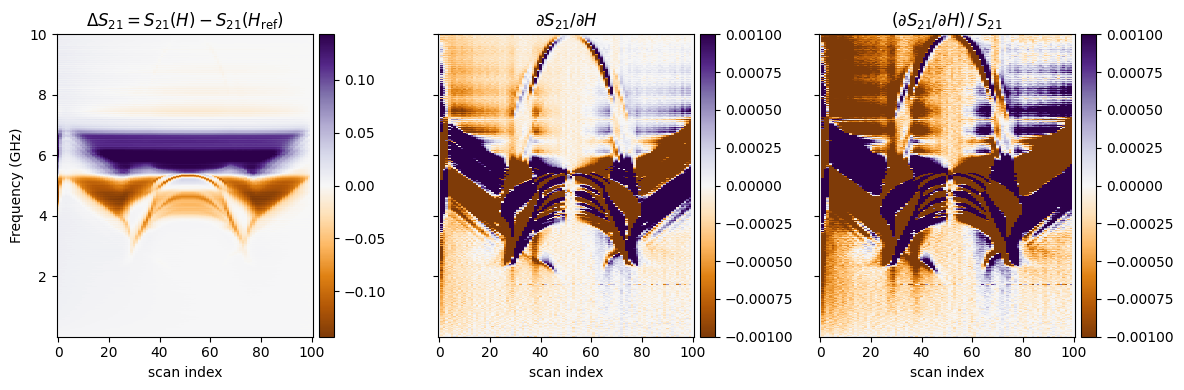

In [4]:
fig, axes = compare_techniques(
    freq, field, mlin,
    saturation_index=int(field.size - 1),   # last (highest-field) scan as ref
    v_min_der=(-1e-3, +1e-3),
    v_min_dd =(-1e-3, +1e-3),
)

## 3. Build a `Spectrum` from in-memory arrays

`Spectrum.from_arrays` is the canonical way to take the data you just
loaded and turn it into a full `Spectrum` object — with derivative-divide
applied, a saturation index recorded, and all the downstream methods
(`plot`, `zoom_plot`, `scatter_plot`, …) available.

Alternative one-liner: `Spectrum.from_mat(DATA_DIR, saturation=200)`.

In [5]:
# Pick the saturation index from the *field value* (last scan, ~200 mT).
# This works on both the full-res (N_field=201) and the bundled
# downsampled (N_field=101) dataset.
sat_idx = int(field.size - 1)

spec = Spectrum.from_arrays(
    freq, field, mlin, mlin_ref,
    saturation=sat_idx,        # field-axis index of the Kittel saturation
    derivative_divide=True,    # background correction
    modulation_amp=1,
    warning=False,
)
print(spec)
print(f'sat_idx={sat_idx},  Msat = {spec.Msat} mT')

<drlib.Spectrum S21 N_field=101 N_freq=2501, B=[0,200], f=[1e+07,1e+10] Hz, mode='derivative_divide', saturation=100>
sat_idx=100,  Msat = 200 mT


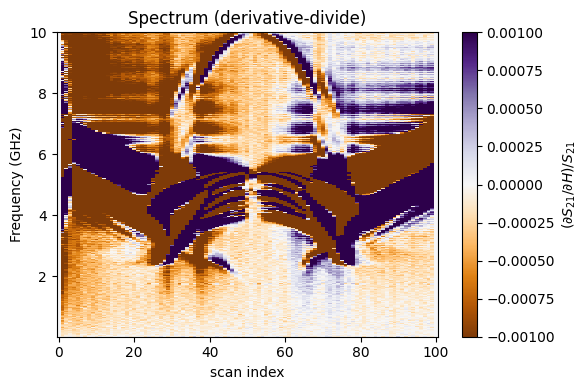

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.pcolormesh(spec.Field, spec.Freq.T * 1e-9, spec.S21dd,
                   vmin=-1e-3, vmax=+1e-3, cmap='PuOr', shading='auto')
ax.set_xlabel('scan index'); ax.set_ylabel('Frequency (GHz)')
ax.set_title('Spectrum (derivative-divide)')
fig.colorbar(im, ax=ax, label=r'$(\partial S_{21}/\partial H)/S_{21}$')
fig.tight_layout()

### Spectrum arithmetic

Spectra with the same shape can be combined directly — useful for
differential measurements (sample minus reference) or for averaging.

In [7]:
spec_d = Spectrum.from_arrays(
    freq, field, mlin, mlin_ref,
    saturation=int(field.size - 1),
    derivative_divide=False, derivative=True, warning=False,
)
print('dd:', spec)
print('d :', spec_d)
# spec * 2, spec / 5, spec - spec_d  all work as plain Spectrum objects.

dd: <drlib.Spectrum S21 N_field=101 N_freq=2501, B=[0,200], f=[1e+07,1e+10] Hz, mode='derivative_divide', saturation=100>
d : <drlib.Spectrum S21 N_field=101 N_freq=2501, B=[0,200], f=[1e+07,1e+10] Hz, mode='derivative', saturation=100>


## 4. `Linecut` &mdash; constant-field cut + `dS21` peak fit

Pick a field-axis index (here scan 80), restrict to a frequency window,
and fit one, two, or three `dS21` peaks with `lmfit`. The model exactly
implements Maeda *et al.*, *AIP Adv.* 8, 075302 (2018), eq. (5).

cut_idx=40  B=80 mT
fres = 4.348 GHz,  Δf = 195 MHz


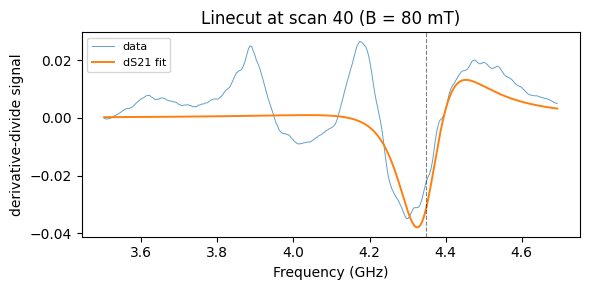

In [8]:
# Pick the scan closest to B = 80 mT (works on both grids)
cut_idx = int(np.argmin(np.abs(field - 80)))
cut = Linecut(cut=cut_idx, Spectrum=spec, frequencies=(3.5e9, 4.7e9))

freq_cut, fit, params, report = cut.one_peak(resonance=[4.2e9])
print('cut_idx={}  B={} mT'.format(cut_idx, cut.H0))
print('fres = {:.3f} GHz,  Δf = {:.0f} MHz'.format(params[2]*1e-9, params[3]*1e-6))

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(cut.Freq_cut * 1e-9, cut.S21dd_cut, label='data', lw=0.7, alpha=0.7)
ax.plot(freq_cut * 1e-9, fit, label='dS21 fit', lw=1.4)
ax.axvline(params[2] * 1e-9, ls='--', lw=0.8, c='k', alpha=0.5)
ax.set_xlabel('Frequency (GHz)'); ax.set_ylabel('derivative-divide signal')
ax.set_title('Linecut at scan {} (B = {} mT)'.format(cut_idx, cut.H0))
ax.legend(fontsize=8); fig.tight_layout()

### Two-peak fit (when two modes overlap)

The `two_peak` / `three_peak` methods take 14- / 21-element initial parameter arrays — see the docstring for the order.

In [9]:
# cut2 = Linecut(cut=80, Spectrum=spec, frequencies=(2.0e9, 5.0e9))
# freq_cut, fit, params = cut2.two_peak(resonance=(3.0e9, 4.3e9))
# # fit is the sum of two dS21 lines; params has 14 entries (7 per peak)

## 5. Series fit overlaid on the spectrum (`scatter_plot`)

Loops `one_peak` over a range of scan indices and overlays the resulting resonance frequencies on top of the colour map. Internally it uses `Spectrum.scatter_fit` which returns the full series of fits if you need the numbers.

In [10]:
# Uncomment to run — fits one Lorentzian per scan in the listed range.
# field_cuts_list  = [np.arange(60, 110)]
# frequencies_list = [(3.8e9, 4.7e9)]
# spec.scatter_plot(field_cuts_list, frequencies_list, colors=['ro'],
#                   v_min=-1e-3, v_max=+1e-3, c_map='PuOr', style=None,
#                   pic_size=(6, 4))

## 6. `CPW` &mdash; Biot–Savart field of a coplanar waveguide

Define the geometry and current; then call any of the three plotting methods.

* `get_Bdistribution` — `B_x(d)` and `B_z(d)` at a fixed height above the plane.
* `get_Bspectrum`     — 2-D quiver/streamplot/contour map of the field.
* `get_Kspectrum`     — FFT of the lateral field profile, i.e. the spin-wave excitation spectrum.

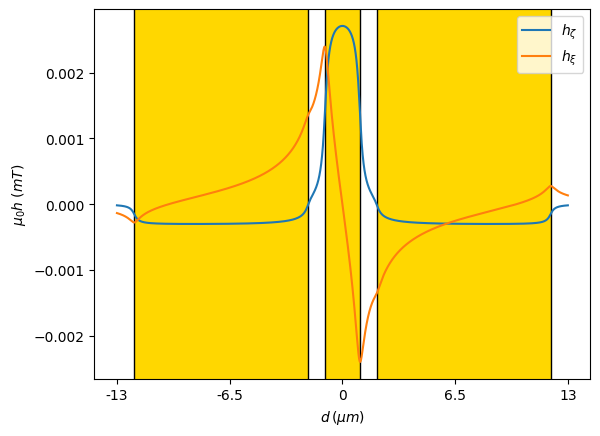

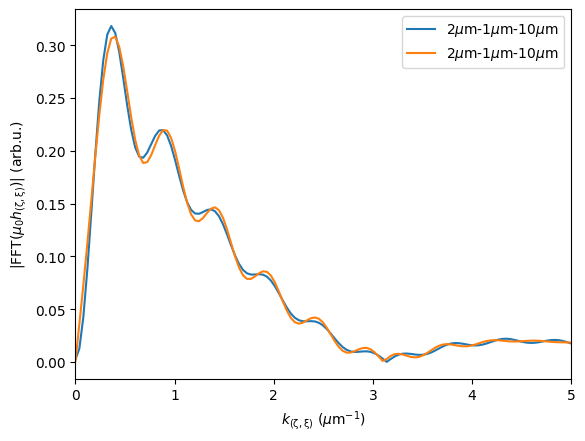

In [11]:
cpw = CPW(
    current     = 10e-3,   # A
    signal_line = 2e-6,    # m
    gap         = 1e-6,    # m
    ground      = 10e-6,   # m
    thickness   = 200e-9,  # m
)

cpw.get_Bdistribution(distance=210e-9, style=None)
cpw.get_Kspectrum(K_range=(0, 5), style=None)

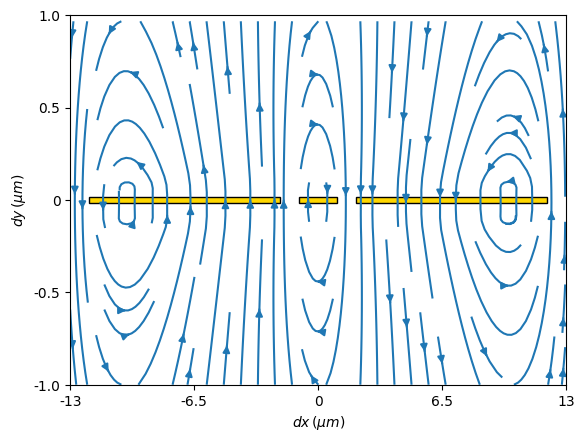

In [12]:
cpw.get_Bspectrum(distance_range=(-1e-6, 1e-6),
                  number_points_XY=(500, 60),
                  plot='streamplot', style=None)

## 7. `REXS2D` &mdash; simulated REXS pattern

Three textures are supported:

* **Skyrmion lattice** (`build_skyrmion_mz`)
* **Helical / single-q modulation** (`build_helical_mz`, `build_helical_multidomain_mz`)
* **Real-space coexistence** of skyrmion patches and helices (`build_skyrmion_plus_helical_coexistence`)

All produce a real-space `m_z(x, y)` and its FFT intensity `I(q_x, q_y)`.

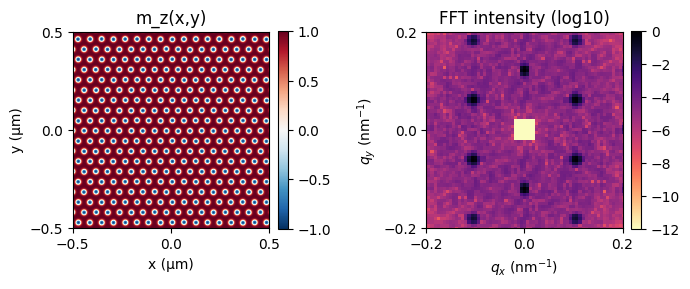

N=256, L=1.000 µm, dx=3.91 nm
pitch=60.0 nm  -> expected |q|≈2π/pitch=0.1047 nm^-1
a=60.0 nm, R0=12.00 nm, w=6.00 nm
Angles used (deg): [0.0]


In [13]:
sim = REXS2D(N=256, L_um=1.0, pitch_nm=60.0, a_nm=60.0, K=1, seed=0)
sim.build_skyrmion_mz()
sim.plot(qmax_nm1=0.2, L_max=0.5, c_mapR='RdBu_r', c_mapQ='magma_r', fig_size=(7, 3.2))
sim.summary()

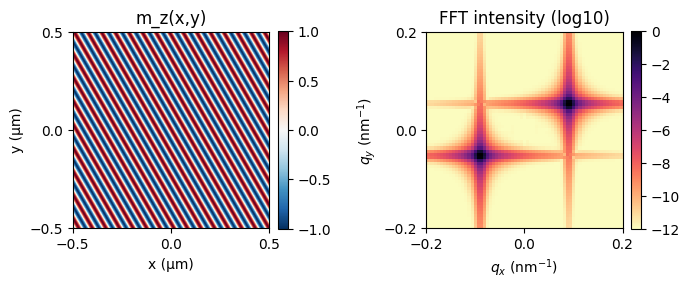

In [14]:
sim2 = REXS2D(N=256, L_um=1.0, pitch_nm=60.0, seed=1)
sim2.build_helical_mz(theta_deg=30.0)
sim2.plot(qmax_nm1=0.2, c_mapR='RdBu_r', c_mapQ='magma_r', fig_size=(7, 3.2))

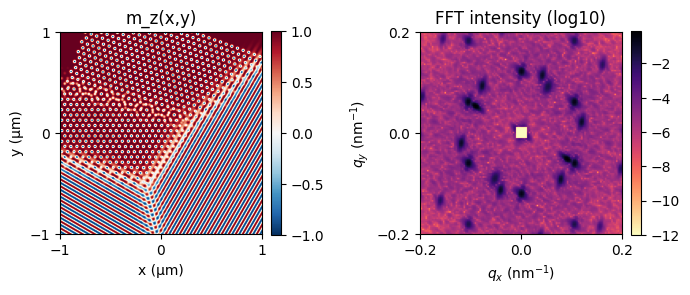

In [15]:
sim3 = REXS2D(N=256, L_um=2.0, pitch_nm=60.0, K=4, seed=2)
sim3.build_skyrmion_plus_helical_coexistence(
    f_sk=0.5,
    skyrmion_angles_deg=[0, 20],
    helix_angles_deg=[-30, 60],
)
sim3.plot(qmax_nm1=0.2, L_max=1.0, c_mapR='RdBu_r', c_mapQ='magma_r', fig_size=(7, 3.2))

## Appendix &mdash; using the LabView folder loader

If your data lives in the original LabView folder layout (see `DATA_SHAPES.md`), use the classical `Spectrum(path=…)` constructor:

```python
spec = Spectrum(
    path=r'C:/data/2024-04-02_FMR_Run3',  # measurement-root folder
    saturation=42,                        # set after a first preview
    derivative_divide=True,
    S_param='S21',                        # which Sxy to load
)
spec.plot()
```

Everything downstream (`Linecut`, `scatter_plot`, arithmetic, …) is identical.